# 🎓 Student Placement Prediction using Machine Learning

## Objective
Develop a machine learning model to predict whether a student will be placed based on academic performance and skills.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#ls -l

In [2]:
cd /content/drive/MyDrive/AIML/placement_project/

/content/drive/MyDrive/AIML/placement_project


In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [4]:
ls -l

total 5712
-rw------- 1 root root  362113 Jul  9 03:05 placement_data.csv
-rw------- 1 root root   50113 Jul 10 03:04 placement.ipynb
-rw------- 1 root root 5424041 Jul  9 15:37 placement_model.pkl
drwx------ 2 root root    4096 Jul  9 14:46 placement_project/
-rw------- 1 root root    5647 Jul  9 15:37 scaler.pkl
-rw------- 1 root root    1777 Jul 10 02:43 Untitled0.ipynb


In [ ]:
data_path = '/content/drive/MyDrive/AIML/placement_project/dataset/placement_data.csv'
df = pd.read_csv(data_path)

In [6]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [ ]:
print(df.shape)

df.info()

df.describe()

In [7]:
print(df.isnull().sum())

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64


In [8]:
df = df.dropna()

In [ ]:
X = df.drop(columns=["Placement", "College_ID"])

y = df["Placement"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

feature_columns = X.columns

Features shape: (10000, 107)
Target shape: (10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print()

print(classification_report(y_test, y_pred))

print()

print(confusion_matrix(y_test, y_pred))

Model Accuracy: 99.95%
None


In [15]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00      1674
         Yes       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



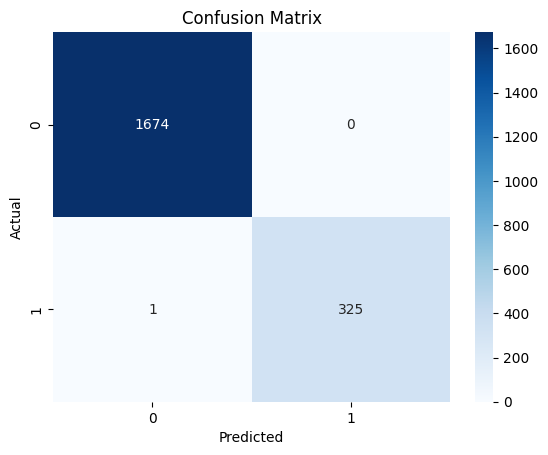

In [16]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model_path = "/content/drive/MyDrive/AIML/placement_project/model/placement_model.pkl"
scaler_path = "/content/drive/MyDrive/AIML/placement_project/model/scaler.pkl"
feature_path = "/content/drive/MyDrive/AIML/placement_project/model/feature_columns.pkl"

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(feature_columns, feature_path)

print("Model Saved Successfully")

✅ Model and Scaler successfully saved to Google Drive!
